In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("train.csv")
# print(df.head())
# print(df.info())
# print(df.describe())
print(df.shape)
print(df.columns)

(1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 

In [17]:
# print(df.isnull())
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [18]:
# df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
# print(df.dropna(subset=['LotFrontage']).shape[0])

# Option 3: Count before and after
print(f"Rows before: {len(df)}")
# df.dropna(subset=['LotFrontage'], inplace=True)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
print(f"Rows after: {len(df)}")
# df.dropna(subset=['Alley'], inplace=True)
print(df.shape)

Rows before: 1460
Rows after: 1460
(1460, 81)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X = df[["LotFrontage", "LotArea", "OverallQual","TotalBsmtSF","LotFrontage","GarageCars"]]
y = df["SalePrice"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [20]:
model = LinearRegression()#Price = w1*feature1 + w2*feature2 + ... + b(y=mx+b)
#price = 100*size + 5000*rooms......so on 
# Takes input (X_train)
# Makes prediction
# Compares with actual (y_train)
# Adjusts weights
# Repeats many times
# 👉 This is optimization

model.fit(X_train,y_train)#Learn pattern from known data
y_pred = model.predict(X_test)#Learn pattern from known data

print(y_pred)
print(y_pred.shape)
# print(y_test.shape)
# print(y_test)


[318691.67963726 212757.42518635 112162.39867525 196123.81356269
 247270.59951429 124573.48254127 241180.79185161 175259.44228615
 195638.35528311 102730.77773055 121573.10803345 142952.42105965
 227889.85980079 250179.40676014 111473.25700479 121862.68074222
 142789.5159911  202823.30246494 114930.5303022  165934.70647778
 231768.27383922 204142.83874001 262459.218607   139334.72921895
 148530.60485197 274581.65236143 188831.93997993 179755.92136648
 170955.91408663 268919.67494301 230755.14319789 142942.74799163
 109924.18403518 214475.86352088 197137.62853188 167239.61486616
 106236.00134176 141666.52460479 163084.12425271 290298.03479906
 133264.26420786  90476.81590754 129514.67742268 202688.28090097
 290584.5282945  124366.96601451 232873.99542834 143981.22849044
 151631.76248815 157930.02567467 230755.14319789 152404.25826023
 111892.47120802 110914.00374934 218254.24156202 161634.29435542
 129382.27427642  86826.7199628  132264.80600621 211716.37017643
 140618.86686633 135672.6

In [21]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

In [22]:
#error jugde
var = mae/(np.mean(df["SalePrice"]))*100
print(var)#On average, your model is off by ~17.28732546012541%

16.017859985968876


In [23]:
model = DecisionTreeRegressor()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
#error jugde
var = mae/(np.mean(df["SalePrice"]))*100
print(var)

19.337030964809756


<Axes: title={'center': 'Distribution of Sale Prices'}, xlabel='Sale Price', ylabel='Density'>

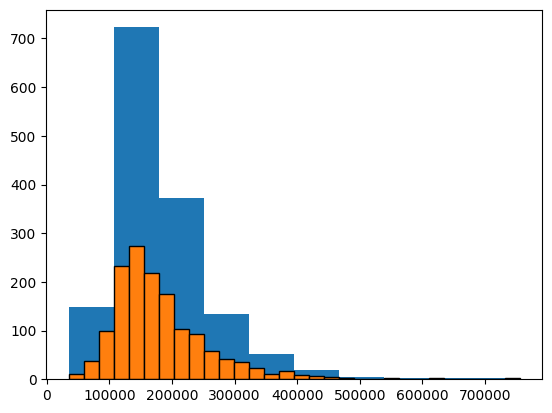

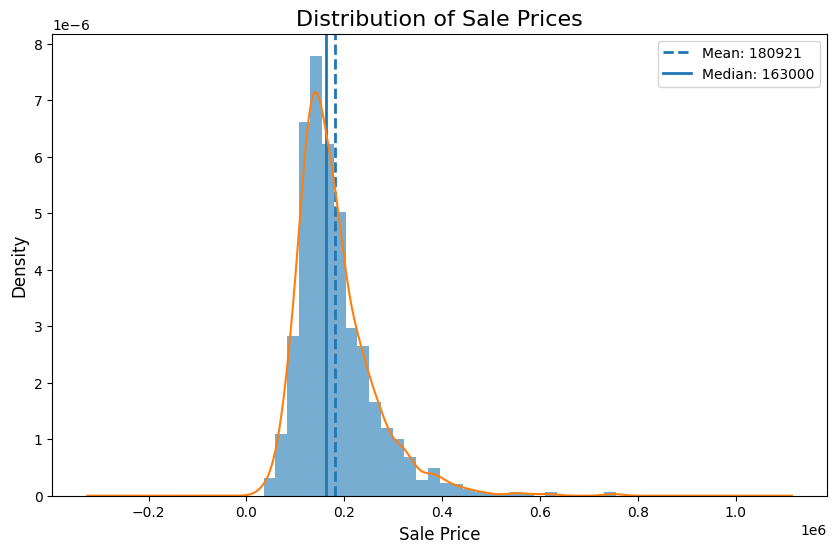

In [28]:
plt.hist(df["SalePrice"])

plt.hist(df["SalePrice"], bins=30, edgecolor='black')

plt.figure(figsize=(10,6))
plt.title("Distribution of Sale Prices", fontsize=16)
plt.xlabel("Sale Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add mean & median lines
mean_val = df["SalePrice"].mean()
median_val = df["SalePrice"].median()

plt.axvline(mean_val, linestyle='dashed', linewidth=2, label=f"Mean: {int(mean_val)}")
plt.axvline(median_val, linestyle='solid', linewidth=2, label=f"Median: {int(median_val)}")

plt.legend()
plt.grid(True)

plt.hist(df["SalePrice"], bins=30, density=True, alpha=0.6)

df["SalePrice"].plot(kind='kde')

# plt.show()